In [4]:
import os
os.chdir("../")

In [98]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import cheby2, butter, filtfilt
from IPython.display import Audio, display

from scipy.fft import fft, ifft

# Параметры сигнала
fs = 8000                
T = 10                   
n_samples = fs * T

np.random.seed(42)
white_noise = np.random.normal(0, 1, n_samples)

t = np.arange(n_samples) / fs

fc_hp = 1000 
order = 4
Wn_hp = fc_hp / (fs/2)

In [99]:
def cheb(data, fs, order=4, cutoff=3000, rs=40):
    nyquist = fs / 2
    normalized_cutoff = cutoff / nyquist
    print(normalized_cutoff)
    b, a = signal.cheby2(order, rs, normalized_cutoff, btype='lowpass', analog=False, output='ba')
    new_data = signal.filtfilt(b, a, data)
    return new_data

def high_filt(data, cutoff=3000):
    filtered = np.where(data > cutoff, 1, 0) * data
    return filtered
    

In [80]:
def spectr(a, fs):
    frequencies, times, Sxx = signal.spectrogram(a, fs,)
    plt.figure(figsize=(8, 4))
    plt.pcolormesh(times, frequencies, 10 * np.log10(Sxx + 1e-10), shading='gouraud')
    plt.ylabel('Частота (Гц)')
    plt.xlabel('Время (с)')
    plt.title('Спектрограмма')
    plt.colorbar(label='Интенсивность (dB)')
    plt.show()

def ach(data, fs):
    time = np.linspace(0, data.shape[0] / fs, num=data.shape[0])
    plt.figure(figsize=(8, 4))
    plt.plot(time, data)
    plt.title('Аудиосигнал')
    plt.xlabel('Время (с)')
    plt.ylabel('Амплитуда')
    plt.grid()
    plt.xlim(0, data.shape[0] / fs)
    plt.show()

def show_graph(data, fs):
    spectr(data, fs)
    ach(data, fs)
    display(Audio(data, rate=fs))
    

''

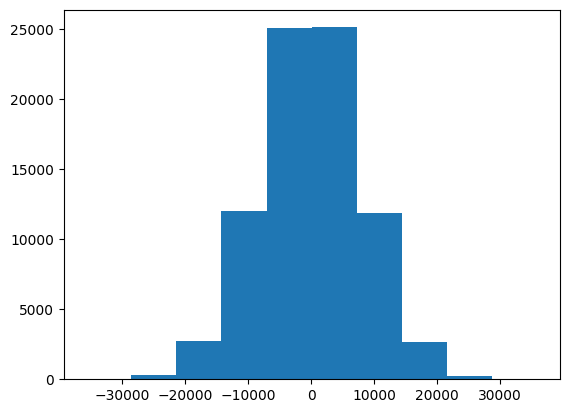

In [81]:
new_white_noise = (white_noise) * fs
plt.hist(new_white_noise)
""

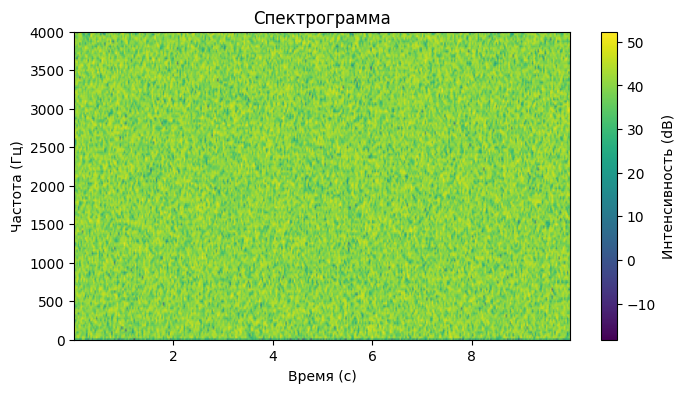

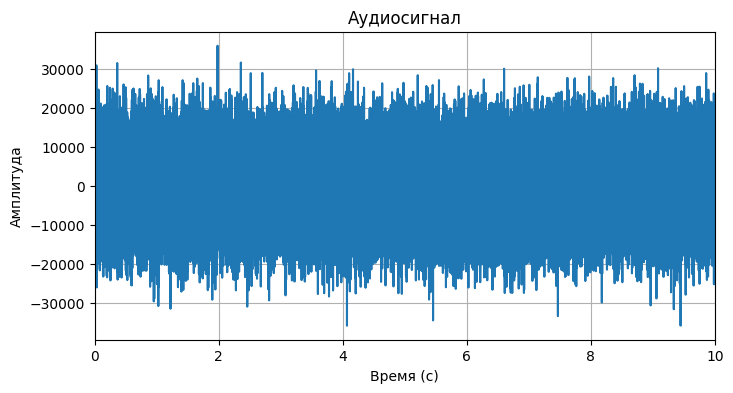

In [82]:
show_graph(new_white_noise, fs=fs)

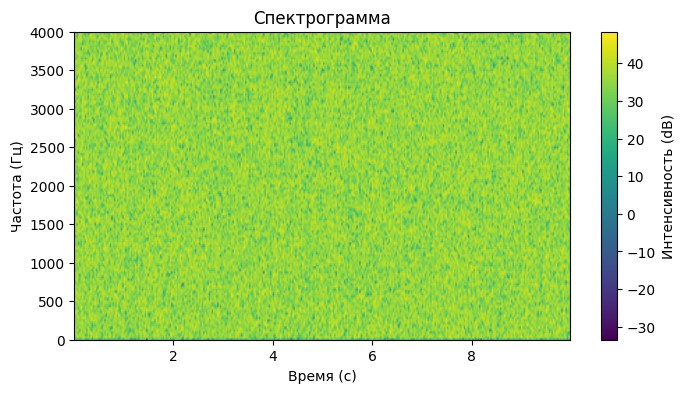

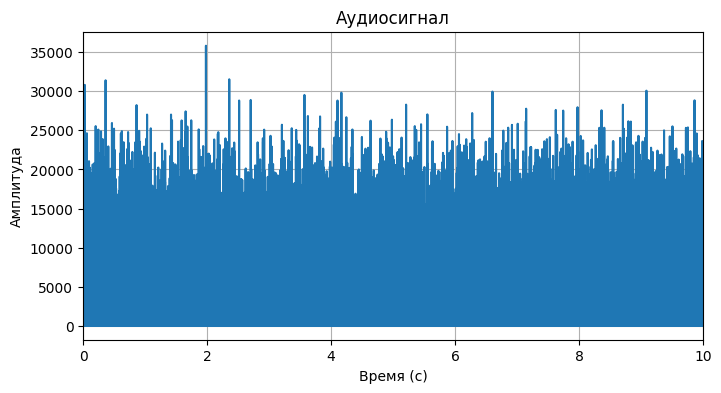

In [102]:
show_graph(high_filt(new_white_noise, cutoff=1000), fs=fs)

0.25


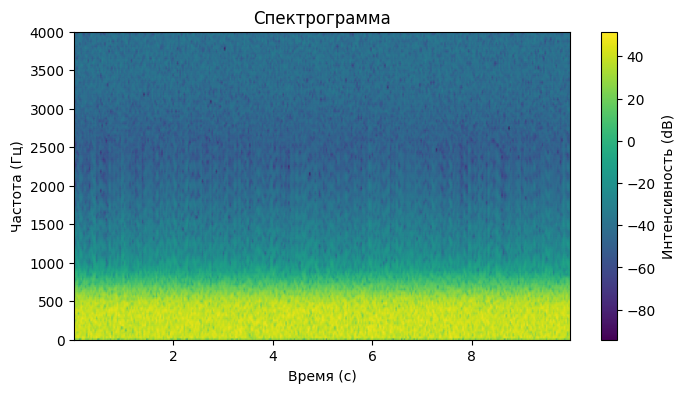

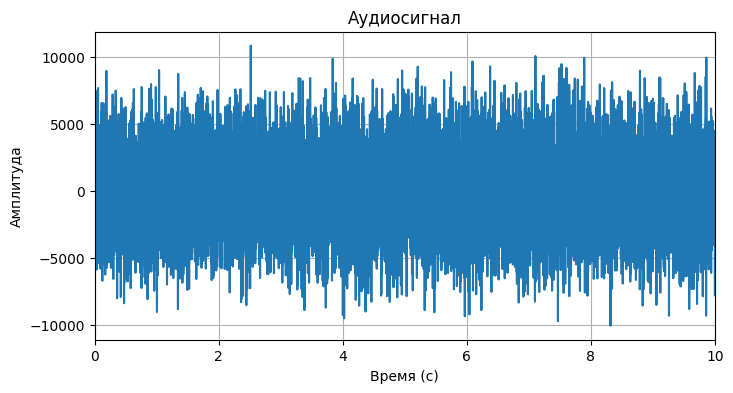

In [103]:
show_graph(cheb(new_white_noise, fs=fs, cutoff=1000), fs=fs)

In [58]:
import scipy.io as io

In [105]:
fs, arr = io.wavfile.read("data/among-us-role-reveal-sound.wav")

In [106]:
channel = arr[:, 0]

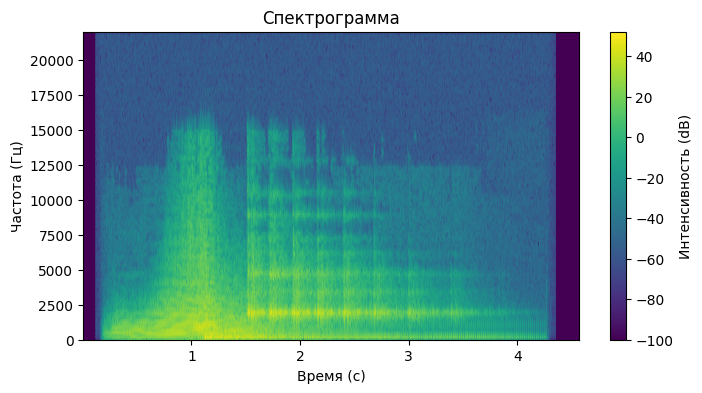

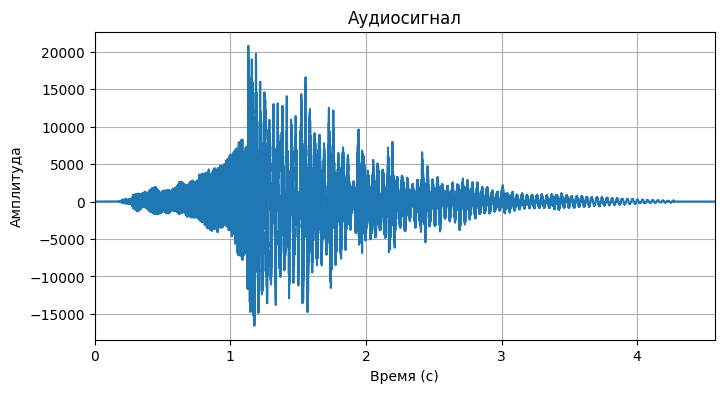

In [107]:
show_graph(channel, fs)

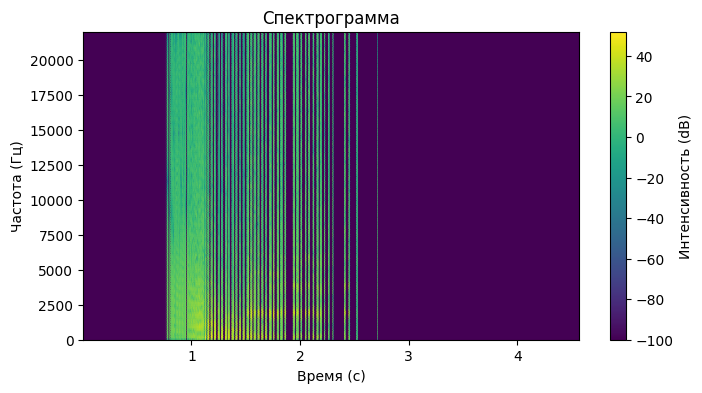

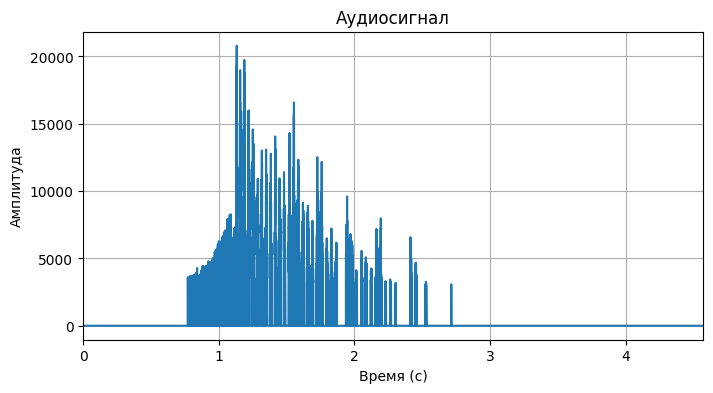

In [108]:
filt = 3000
show_graph(high_filt(channel), fs)

0.045351473922902494


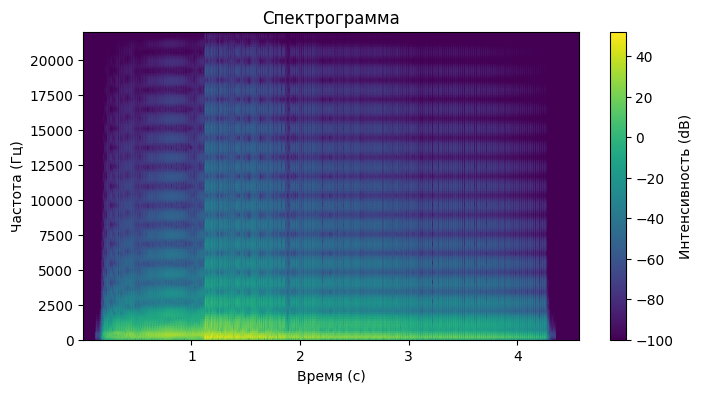

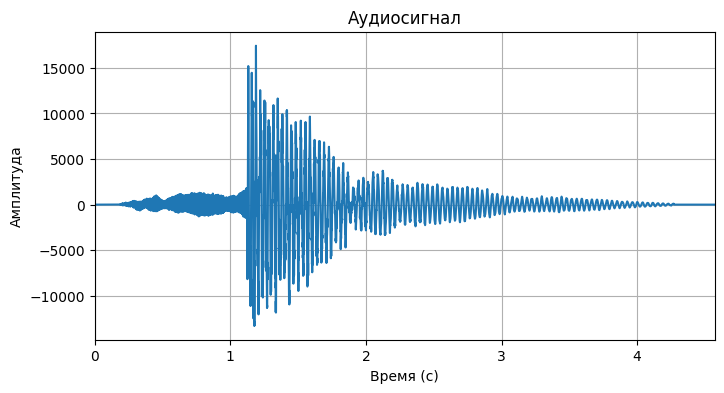

In [109]:
show_graph(cheb(channel, fs=fs, cutoff=1000), fs=fs)

0.045351473922902494


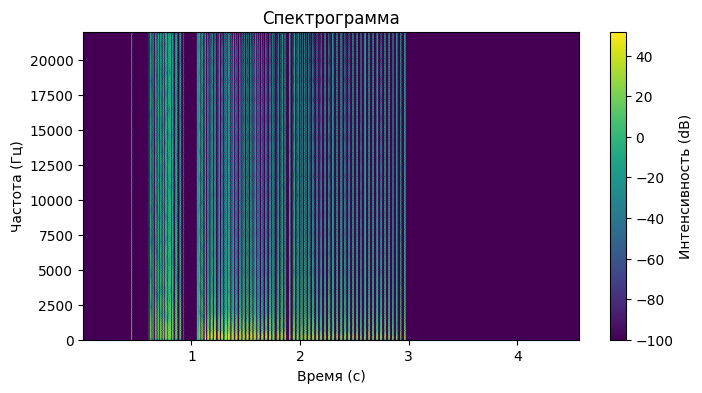

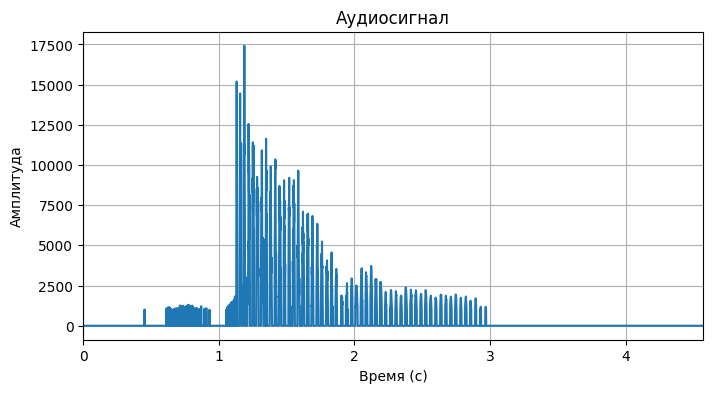

0.045351473922902494


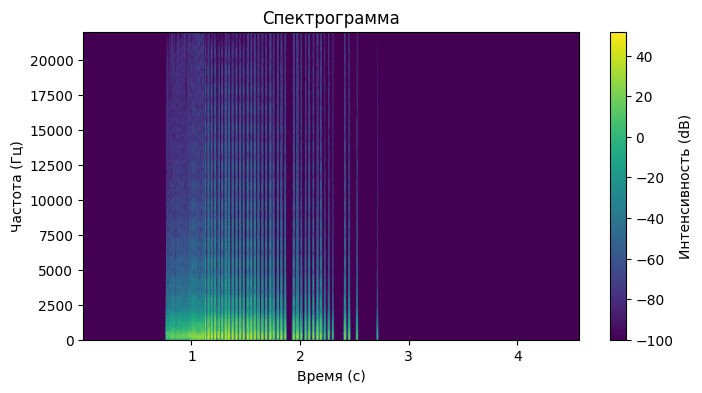

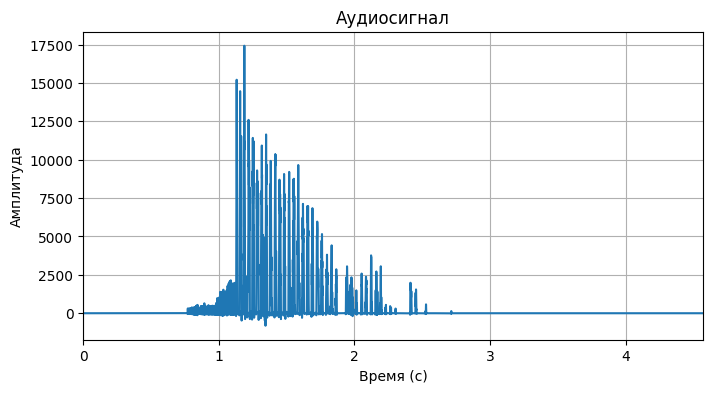

In [112]:
show_graph(high_filt(cheb(channel, fs=fs, cutoff=1000), cutoff=1000), fs=fs)

show_graph(cheb(high_filt(channel, cutoff=3000), fs=fs, cutoff=1000), fs=fs)